In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from os import environ
import os
import os

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic-bias")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

dry = False # whether or not to save results

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/wbic-bias


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [5]:
from sklearn_extensions.mixbinom import BinomialMixture
import numpy as np


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
  return truth

In [6]:
wbic_df = pd.read_csv(f"{outputdir}/fe_by_ti.csv")

In [9]:
# Prep data
wbic_df['error'] = wbic_df['wbic'] - wbic_df['fe']
wbic_df['normalized_error'] = (wbic_df['wbic'] - wbic_df['fe'])/np.log(wbic_df['fe'])
wbic_df['Model'] = wbic_df['n_components'].map({2: 'K=2', 3: 'K=3', 5: 'K=5'})
wbic_df.head()

,dsid,regime,n,trial,wbic,fe,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components,error,Model,normalized_error
0,regular,50,50,0,166.973538,169.480808,1,1000,2500,0.0,0,0,[0],5,2,-2.507270,K=2,-0.488486
1,e-singular,50,50,0,160.859504,162.214551,1,1000,2500,0.0,0,0,[0],7,2,-1.355047,K=2,-0.266274
2,singular1,50,50,0,143.926150,145.520635,1,1000,2500,0.0,0,0,[0],8,2,-1.594485,K=2,-0.320157
3,singular2,50,50,0,153.828493,155.222949,1,1000,2500,0.0,0,0,[0],8,2,-1.394457,K=2,-0.276411
4,regular,250,250,0,842.389216,844.913288,1,1000,2500,0.0,0,0,[0],5,2,-2.524072,K=2,-0.374534


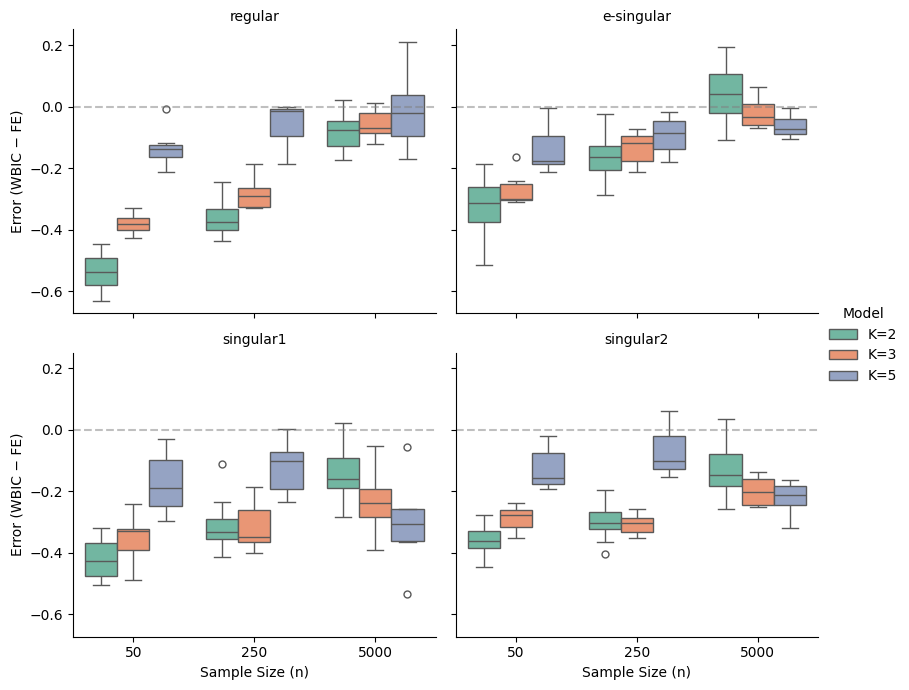

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='normalized_error',
    hue='Model',
    col='dsid',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Error (WBIC − FE)')
g.set_titles(col_template='{col_name}')

# plt.tight_layout()
plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated convergence rates (RMSE ~ n^(-α)):
      dsid Model     alpha  intercept  r_squared
e-singular   K=2  0.132883   0.977820   0.906175
e-singular   K=3  0.194900   1.042978   0.948898
   regular   K=2  0.247787   2.096700   0.942295
   regular   K=3  0.225951   1.705579   0.905468
 singular1   K=2  0.092518   1.163624   0.873926
 singular1   K=3 -0.071632   0.260246   0.966422
 singular2   K=2  0.035104   0.780366   0.461860
 singular2   K=3 -0.068474   0.197228   0.483960


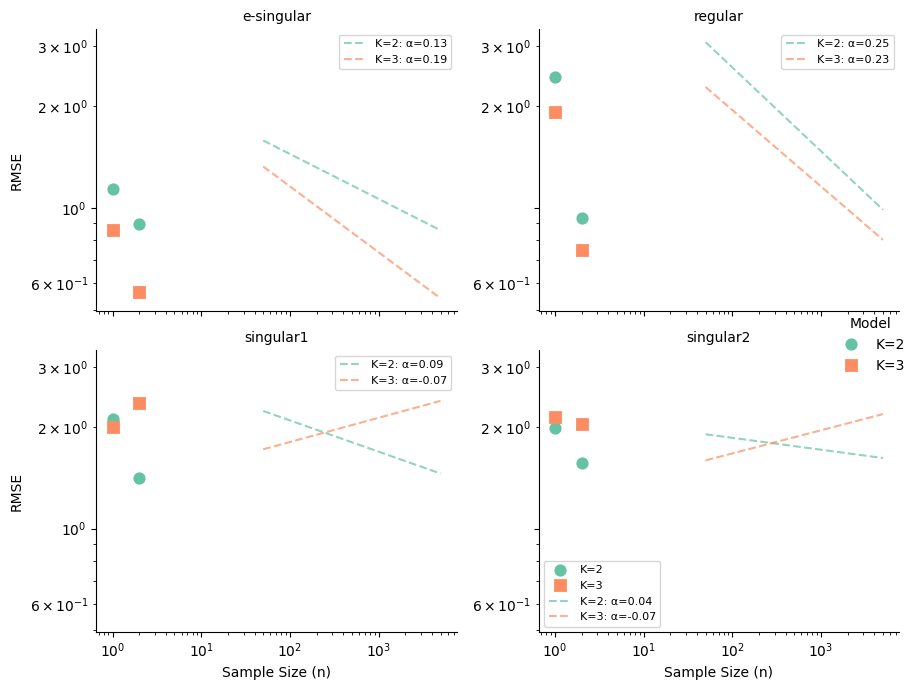


Convergence rates summary:
Model         K=2    K=3
dsid                    
e-singular  0.133  0.195
regular     0.248  0.226
singular1   0.093 -0.072
singular2   0.035 -0.068


In [45]:
from scipy import stats


# Aggregate: RMSE per (dsid, n, model)
summary = wbic_df.groupby(['dsid', 'n', 'Model']).agg(
    rmse=('error', lambda x: np.sqrt(np.mean(x**2)))
).reset_index()

# Log transform for regression
summary['log_n'] = np.log(summary['n'])
summary['log_rmse'] = np.log(summary['rmse'])

# Fit convergence rate for each (dsid, Model)
def fit_rate(group):
    slope, intercept, r, p, se = stats.linregress(group['log_n'], group['log_rmse'])
    return pd.Series({
        'alpha': -slope,
        'intercept': intercept,
        'r_squared': r**2
    })

rates = summary.groupby(['dsid', 'Model']).apply(fit_rate).reset_index()
print("Estimated convergence rates (RMSE ~ n^(-α)):")
print(rates.to_string(index=False))

# Plot using catplot
g = sns.catplot(
    data=summary,
    x='n',
    y='rmse',
    hue='Model',
    col='dsid',
    kind='point',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2',
    markers=['o', 's'],
    linestyles=['', '']
)

# Add fitted convergence lines
for ax, dsid in zip(g.axes.flat, summary['dsid'].unique()):
    subset = summary[summary['dsid'] == dsid]
    n_vals = sorted(subset['n'].unique())
    n_range = np.linspace(min(n_vals), max(n_vals), 100)
    
    for model, color in zip(['K=2', 'K=3'], sns.color_palette('Set2')):
        rate_row = rates[(rates['dsid'] == dsid) & (rates['Model'] == model)]
        if len(rate_row) == 0:
            continue
        alpha = rate_row['alpha'].values[0]
        intercept = rate_row['intercept'].values[0]
        
        fitted = np.exp(intercept) * n_range ** (-alpha)
        ax.plot(n_range, fitted, color=color, linestyle='--', alpha=0.7,
                label=f'{model}: α={alpha:.2f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

g.set_axis_labels('Sample Size (n)', 'RMSE')
g.set_titles(col_template='{col_name}')

# plt.savefig('wbic_convergence_rmse.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Print summary table
print("\nConvergence rates summary:")
pivot = rates.pivot(index='dsid', columns='Model', values='alpha')
print(pivot.round(3))